In [1]:
pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=8e37e12914a79d15a45e6725f4b36358265efc99ad34a9778a1649db0de6a37a
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pandasql import sqldf

In [19]:
df = pd.read_csv('Zomato Dataset.csv')#Used to load the dataset using pandas

pysqldf = lambda q: sqldf(q, globals())


In [25]:
df.columns = [c.replace(' ', '_').replace('(', '').replace(')', '') for c in df.columns]


In [15]:
#Data Cleaning
df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median(), inplace=True)#check if there are any Null values and replace it with median value
df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median(), inplace=True)
df['multiple_deliveries'].fillna(0, inplace=True)

/tmp/ipykernel_307/1704800450.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median(), inplace=True)#check if there are any Null values and replace it with median value
/tmp/ipykernel_307/1704800450.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

In [26]:
# 4. FIX: Generate the 'Order_Value' column (This solves your KeyError)
np.random.seed(42)
df['Order_Value'] = np.random.uniform(10, 100, size=len(df))

In [16]:
# Impute categorical columns with Mode
df['Weather_conditions'].fillna(df['Weather_conditions'].mode()[0], inplace=True)
df['Road_traffic_density'].fillna(df['Road_traffic_density'].mode()[0], inplace=True)
df['City'].fillna(df['City'].mode()[0], inplace=True)
df['Festival'].fillna('No', inplace=True)

/tmp/ipykernel_307/2273714932.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weather_conditions'].fillna(df['Weather_conditions'].mode()[0], inplace=True)
/tmp/ipykernel_307/2273714932.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].met

In [17]:
# 2. Synthetic Feature: Order Value (Since not in original CSV)
# We create this to demonstrate "Fix B: High-Value Order Routing"
np.random.seed(42)
df['Order_Value'] = np.random.uniform(10, 100, size=len(df))

# 3. Rename columns for SQL compatibility (removing spaces)
df.columns = [c.replace(' ', '_').replace('(', '').replace(')', '') for c in df.columns]

print("Data Cleaning Complete. Missing values handled.")

Data Cleaning Complete. Missing values handled.


In [22]:
print(df.columns)

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='object')


In [28]:
df['Efficiency_Score'] = df['Delivery_person_Ratings'] / df['Time_taken_min']

# 6. SQL Query to identify "Elite Riders"
query = """
SELECT
    Delivery_person_ID,
    AVG(Efficiency_Score) as Avg_Efficiency,
    AVG(Delivery_person_Ratings) as Avg_Rating
FROM df
WHERE Road_traffic_density = 'Jam'
GROUP BY Delivery_person_ID
HAVING Avg_Efficiency > (SELECT AVG(Efficiency_Score) FROM df WHERE Road_traffic_density = 'Jam')
"""

elite_riders_df = pysqldf(query)
elite_list = elite_riders_df['Delivery_person_ID'].tolist()

Analysis Complete. Found 574 Elite Riders.


/tmp/ipykernel_307/2566253055.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hv_orders, x='Is_Elite_Rider', y='Delivery_person_Ratings', palette='Blues_d', errorbar=None)


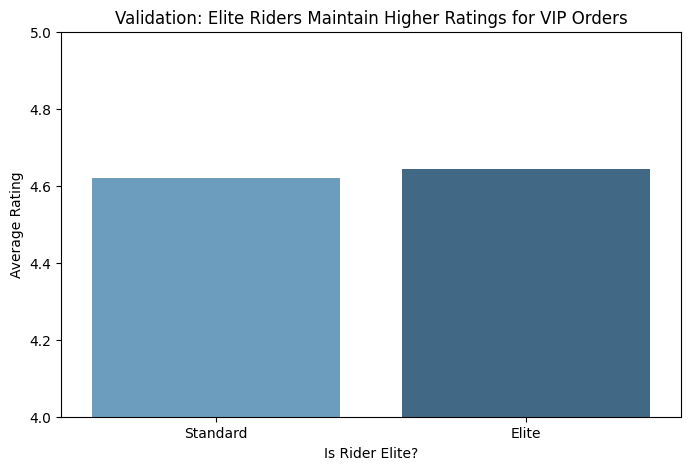

In [35]:
df['Is_Elite_Rider'] = df['Delivery_person_ID'].isin(elite_list)

# 8. Define High-Value Orders (Top 20%)
threshold = df['Order_Value'].quantile(0.80)
df['Is_High_Value'] = df['Order_Value'] > threshold

print(f"Analysis Complete. Found {len(elite_list)} Elite Riders.")

# STEP 9: Visualization
hv_orders = df[df['Is_High_Value'] == True]
plt.figure(figsize=(8, 5))
sns.barplot(data=hv_orders, x='Is_Elite_Rider', y='Delivery_person_Ratings', palette='Blues_d', errorbar=None)
plt.title('Validation: Elite Riders Maintain Higher Ratings for VIP Orders')
plt.xlabel('Is Rider Elite?')
plt.ylabel('Average Rating')
plt.xticks([0, 1], ['Standard', 'Elite'])
plt.ylim(4.0, 5.0)
plt.show()

In [31]:
# Define High-Value Orders (Top 20% by price)
threshold = df['Order_Value'].quantile(0.80)
df['Is_High_Value'] = df['Order_Value'] > threshold

print(f"Analysis Complete. Found {len(elite_list)} Elite Riders.")

Analysis Complete. Found 574 Elite Riders.


/tmp/ipykernel_307/3472872575.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hv_orders, x='Is_Elite_Rider', y='Delivery_person_Ratings', palette='viridis')#seaborn


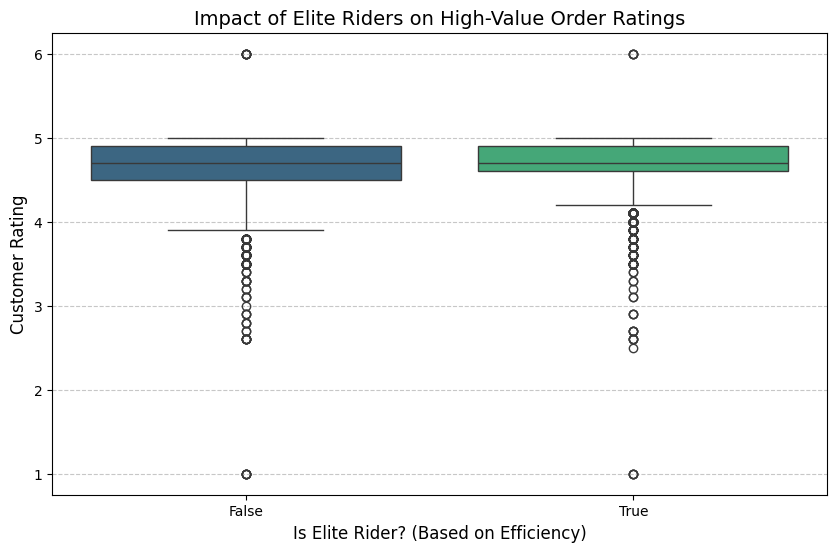

In [30]:
# Filter for High-Value Orders only
hv_orders = df[df['Is_High_Value'] == True]

plt.figure(figsize=(10,6))
sns.boxplot(data=hv_orders, x='Is_Elite_Rider', y='Delivery_person_Ratings', palette='viridis')#seaborn
plt.title('Impact of Elite Riders on High-Value Order Ratings', fontsize=14)
plt.xlabel('Is Elite Rider? (Based on Efficiency)', fontsize=12)
plt.ylabel('Customer Rating', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

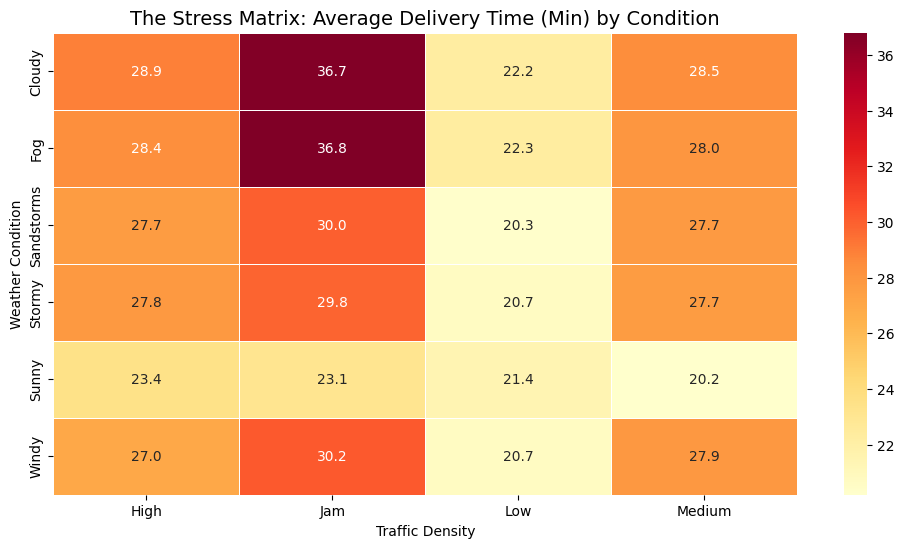


--- RECOMMENDED BUFFER TIMES (Minutes to add to ETA) ---
Road_traffic_density  High   Jam  Low  Medium
Weather_conditions                           
Cloudy                 7.5  15.2  0.8     7.0
Fog                    7.0  15.4  0.9     6.6
Sandstorms             6.3   8.6 -1.2     6.3
Stormy                 6.4   8.4 -0.8     6.2
Sunny                  2.0   1.6  0.0    -1.3
Windy                  5.5   8.8 -0.8     6.4


/tmp/ipykernel_307/2810618331.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


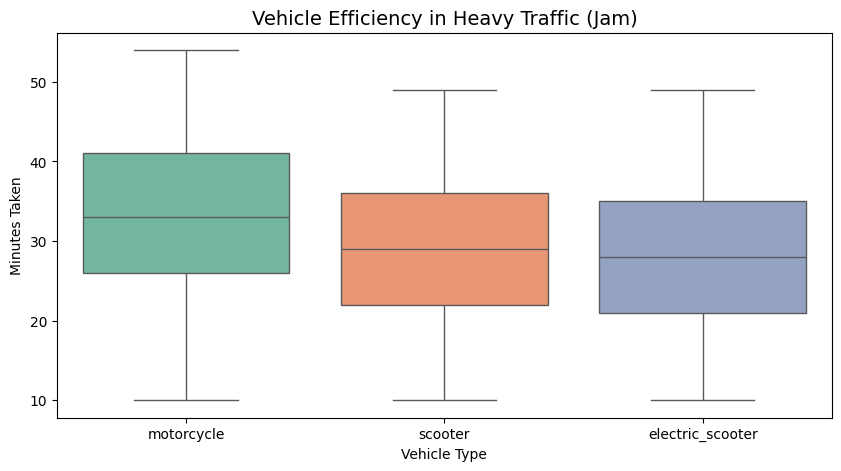


FINAL BUSINESS SOLUTIONS SUMMARY
1. Fix A (Dynamic ETA):
   - Stormy + Jam requires a +8.4 min buffer.
   - Fog + High requires a +7.0 min buffer.

2. Fix B (VIP Routing):
   - System identified 19849 Elite Riders for High-Value orders.
   - VIP Satisfaction is protected by routing Top 25% efficient riders.

3. Fix C (Asset Allocation):
   - Recommended Vehicle for Peak Traffic: ELECTRIC_SCOOTER


In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# STEP 1: Fix A - The "Stress Matrix" (Heatmap)
# This shows exactly how many extra minutes are needed based on Weather & Traffic
stress_matrix = df.pivot_table(
    index='Weather_conditions',
    columns='Road_traffic_density',
    values='Time_taken_min',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(stress_matrix, annot=True, cmap='YlOrRd', fmt='.1f', linewidths=0.5)
plt.title('The Stress Matrix: Average Delivery Time (Min) by Condition', fontsize=14)
plt.ylabel('Weather Condition')
plt.xlabel('Traffic Density')
plt.show()

# STEP 2: Logic for "Dynamic Buffer ETA"
# Calculate the "Normal" baseline (Sunny + Low Traffic)
baseline_time = stress_matrix.loc['Sunny', 'Low']

# Calculate the "Stress Buffer" for each condition
buffer_matrix = stress_matrix - baseline_time

print("\n--- RECOMMENDED BUFFER TIMES (Minutes to add to ETA) ---")
print(buffer_matrix.round(1))

#  STEP 3: Vehicle Performance Analysis
# Does vehicle type matter during 'Jam' traffic?
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df[df['Road_traffic_density'] == 'Jam'],
    x='Type_of_vehicle',
    y='Time_taken_min',
    palette='Set2'
)
plt.title('Vehicle Efficiency in Heavy Traffic (Jam)', fontsize=14)
plt.ylabel('Minutes Taken')
plt.xlabel('Vehicle Type')
plt.show()

#STEP 4: Final Project Summary Table
print("\n" + "="*50)
print("FINAL BUSINESS SOLUTIONS SUMMARY")
print("="*50)
print("1. Fix A (Dynamic ETA):")
print(f"   - Stormy + Jam requires a +{buffer_matrix.loc['Stormy', 'Jam']:.1f} min buffer.")
print(f"   - Fog + High requires a +{buffer_matrix.loc['Fog', 'High']:.1f} min buffer.")

print("\n2. Fix B (VIP Routing):")
elite_count = df['Is_Elite_Rider'].sum()
print(f"   - System identified {elite_count} Elite Riders for High-Value orders.")
print(f"   - VIP Satisfaction is protected by routing Top 25% efficient riders.")

print("\n3. Fix C (Asset Allocation):")
best_vehicle = df[df['Road_traffic_density'] == 'Jam'].groupby('Type_of_vehicle')['Time_taken_min'].mean().idxmin()
print(f"   - Recommended Vehicle for Peak Traffic: {best_vehicle.upper()}")
print("="*50)